# Preference for Experimentation

Julian Hsu

Initial version: 2025-05-01

Current version: 2026-06-10


## Problem Setup
We run an experiment where we decide the proportion p of users to assign to treatment each round. Treatment has a negative effect on reward, so the optimal policy is to assign everyone to control — but the agent does not know this upfront.

Both arms have the **same within-arm noise** σ². Therefore the pooled outcome variance is:

$$\text{Var}(Y) = \sigma^2 + p(1-p)(\bar{\mu}_T - \bar{\mu}_C)^2$$

Note this means that variance peaks when we maximize power with p = 0.5. It diminishes and is at its minimum at the corners (p → 0 or p → 1).

### Myopic Loss function

The agent minimises an objective function based on the total outcome of that period, the variance of that outcome, and now certain it is in the correct decision. These are two variance components. There is uncertainty over what the correct outcome is. The agent uses it's expectation of the total outcome of that period, and the expected variance. To measure certain in its decision, we use the Fisher information of the average treatment effect (ATE) of the treatment arm. 

The expectation of the ATE and its noise are continuously updated as the agent collects more data. 

$$L(p) = -\underbrace{\bigl[p\bar{\mu}_T + (1-p)\bar{\mu}_C\bigr]}_{\text{expected reward}} + \lambda \underbrace{\bigl[\sigma^2 + p(1-p)(\bar{\mu}_T - \bar{\mu}_C)^2\bigr]}_{\text{outcome variance}} - \eta \underbrace{\frac{n \cdot p(1-p)}{\sigma^2}}_{\text{Fisher info for ATE}}$$

where $\bar{\mu}_T$, $\bar{\mu}_C$ are the **observed sample means** from accumulated data — the agent uses point estimates only.

- **λ** (variance aversion): penalises outcome variance. High λ → agent prefers corners to eliminate the between-arm term.
- **η** (experimentation incentive): rewards Fisher information. High η → agent prefers balanced allocation to maximise ATE precision.

### Drawbacks of Myopic Loss Function
A major drawback is that we assume the agent is only maximizing the immediate payoff. The ideal is for the agent to sovle a dynamic programming problem where it deliberately tries to learn. We have abstracted away from this and these go into the interpretation of the **λ** and **η** parameters. It also means that we cannot directly model how preferences can change over time. For example, an agent with fewer periods to decide my not want to experiment and learn at all. **This** will be why we cannot get the dynamics we want.

We will find that agents with only some nyopic preference for experimentation will allocate little but enough sample over time that they will end up making the right decisions. Those with a myopic preference for experimentation will allocate too much and learn, but those learnings become useless later on. 




### Interior vs. corner optimum

The curvature of L in p is:

$$\frac{d^2 L}{dp^2} = -2\lambda(\bar{\mu}_T - \bar{\mu}_C)^2 + \frac{2\eta n}{\sigma^2}$$

The sign determines whether corners or an interior allocation wins:

| Condition | Curvature | Optimal p |
|---|---|---|
| λ > λ* = η n / (σ²·gap²) | Negative (concave) | Corner (0 or 1) |
| λ < λ* | Positive (convex) | Interior (~0.5) |

With n = 50, σ = 9, true gap = 3: **λ* = η / 14.58**.

**Initialization:** Before round 1, the agent draws 3 observations from each arm at random. This seeds the point estimates so the loss function is defined from the very first round.

In [11]:
## Import necessary llibraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)


## Warm-Up Initialization

Before round 1, the agent draws **3 observations from each arm** using the true DGP. These 3 draws seed the sample means $\bar{\mu}_T$ and $\bar{\mu}_C$ so the loss function has something to evaluate from the very first round. The warm-up is deliberately small (3 obs) to keep the early-round behaviour interesting.

With only 6 total arm-up observations, the initial point estimates are noisy and the agent may start at an unfavourable corner. As the main loop accumulates the estimates sharpen quickly.



In [12]:
## Create functions for the loss and policy of choosing proportion to experiment with

In [13]:
def loss(reward, variance, info_gain, lambda_weight, eta):
    """L(p) = -reward + lambda*variance - eta*info_gain.

    variance  = sigma^2 + p(1-p)*(mu_T - mu_C)^2  [pooled outcome variance]
    info_gain = p*(1-p)*n/sigma^2                  [Fisher information for ATE]

    Curvature: d^2L/dp^2 = -2*lambda*(mu_T-mu_C)^2 + 2*eta*n/sigma^2
      > 0 (convex, interior optimum) when  eta * n/sigma^2 > lambda * (mu_T-mu_C)^2
      < 0 (concave, corner optimum)   when  lambda > lambda* = eta*n / (sigma^2*(mu_T-mu_C)^2)
    """
    return -reward + lambda_weight * variance - eta * info_gain


def choose_best_allocation(treatment_outcomes, control_outcomes, p_grid, lambda_weight, eta=0.0):
    """Grid-search over p using point estimates of arm means.

    Requires at least one observation per arm -- callers must guarantee this
    via a warm-up phase before the main loop.
    """
    T_bar = np.mean(treatment_outcomes)
    C_bar = np.mean(control_outcomes)
    var_known = noise_treat ** 2

    best_loss_val = float('inf')
    best_p = p_grid[len(p_grid) // 2]
    for p in p_grid:
        reward    = p * T_bar + (1 - p) * C_bar
        variance  = var_known + p * (1 - p) * (T_bar - C_bar) ** 2
        info_gain = p * (1 - p) * n_per_round / var_known
        cur = loss(reward, variance, info_gain, lambda_weight, eta)
        ## Taking the smallest one. 
        if cur < best_loss_val:
            best_loss_val = cur
            best_p = p
    return best_p


In [14]:
def outputs(lambda_weight=None, eta=0.0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    allocation_history = []
    cumulative_reward_history = []
    total_reward = 0

    # Warm-up: 3 random observations per arm before any loss-based allocation.
    # This guarantees point estimates exist from round 1 onward.
    treatment_outcomes = list(true_effect + np.random.normal(0, noise_treat, 3))
    control_outcomes   = list(np.random.normal(0, noise_control, 3))

    for t in range(T):
        best_p = choose_best_allocation(
            treatment_outcomes, control_outcomes, p_grid, lambda_weight, eta)

        n_treat   = min(max(int(round(n_per_round * best_p)), 1), n_per_round - 1)
        n_control = n_per_round - n_treat
        allocation_history.append(n_treat / n_per_round)

        treat_outcomes_round = true_effect + np.random.normal(0, noise_treat, n_treat)
        cont_outcomes_round  = np.random.normal(0, noise_control, n_control)

        treatment_outcomes.extend(treat_outcomes_round)
        control_outcomes.extend(cont_outcomes_round)

        total_reward += np.sum(treat_outcomes_round) + np.sum(cont_outcomes_round)
        cumulative_reward_history.append(total_reward)

    return {
        "allocations": allocation_history,
        "cumulative_rewards": cumulative_reward_history,
    }


## DGP and Ground Truth Parameters
Note that the agent NEVER sees these values -- it only observes realized outcomes.


In [15]:
###### Parameters
true_effect   = -1     # treatment lowers the outcome; optimal policy is all-control
noise_control = 9      # both arms have equal noise
noise_treat   = 9     # equal noise means only the between-arm term varies with p


In [21]:

n_per_round   = 10     # users assigned each round
T             = 100     # number of rounds
p_grid        = np.linspace(0.05, 0.95, 19)   # candidate treatment proportions


In [27]:

eta_fixed    = 15.0
lambda_values = [0.0, 0.5 , 2.0]

lambda_fixed = 0.5
eta_values   = [0.0, 10.0, 50.0]

n_runs = 50
seeds  = list(range(n_runs))   # each run uses the same seed across all conditions

results_lambda_sweep = {
    lw: [outputs(lambda_weight=lw, eta=eta_fixed, seed=s) for s in seeds]
    for lw in lambda_values
}
results_eta_sweep = {
    ev: [outputs(lambda_weight=lambda_fixed, eta=ev, seed=s) for s in seeds]
    for ev in eta_values
}

def to_df(results, key):
    return pd.DataFrame([run[key] for run in results])

alloc_lambda  = {lw: to_df(results_lambda_sweep[lw], "allocations")       for lw in lambda_values}
cumrew_lambda = {lw: to_df(results_lambda_sweep[lw], "cumulative_rewards") for lw in lambda_values}
alloc_eta     = {ev: to_df(results_eta_sweep[ev],    "allocations")        for ev in eta_values}
cumrew_eta    = {ev: to_df(results_eta_sweep[ev],    "cumulative_rewards") for ev in eta_values}


In [28]:
## Recall loss function is:
## -Outcome + \lambda *  variance - \eta * fisher information 
## We want to *minimize* loss. Therefore we want a large outcome, small variance, and large fisher information.
## So as lambda get bigger, the agent cares more about variance and is willing to experiment less to reduce the lambda*variance term. 
## So as eta get bigger, the agent cares more about information gain and is willing to experiment more 

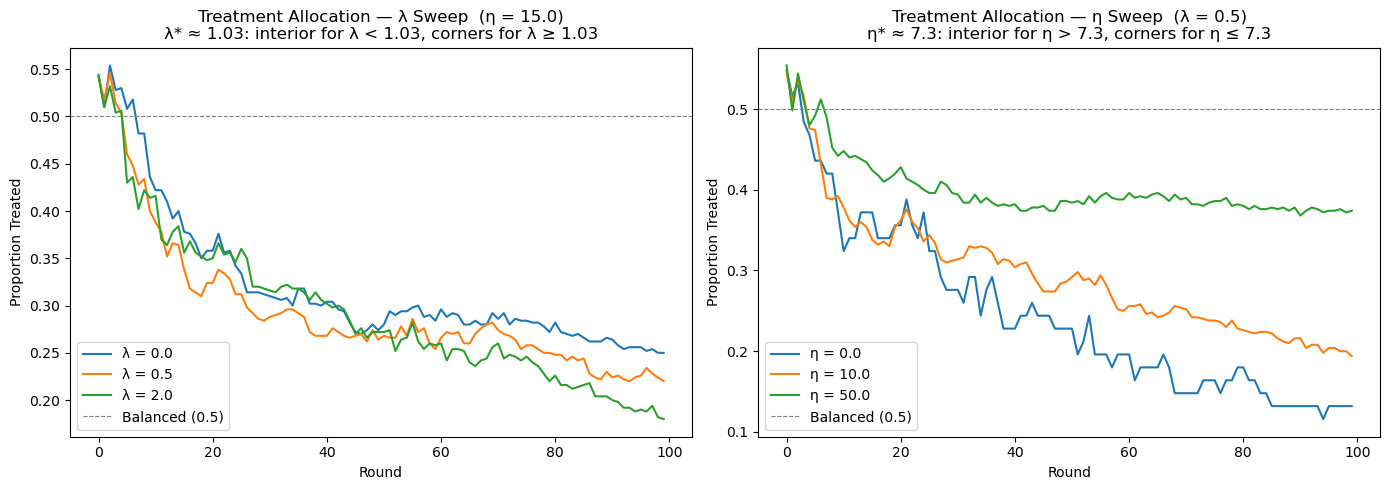

In [29]:
rounds = np.arange(T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: lambda sweep (eta fixed)
ax = axes[0]
for lw in lambda_values:
    m = alloc_lambda[lw].mean()
    s = alloc_lambda[lw].std()
    ax.plot(rounds, m.values, label=f'λ = {lw}')
    # ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Balanced (0.5)')
ax.set_title(f'Treatment Allocation — λ Sweep  (η = {eta_fixed})\nλ* ≈ 1.03: interior for λ < 1.03, corners for λ ≥ 1.03')
ax.set_xlabel('Round')
ax.set_ylabel('Proportion Treated')
ax.legend()

# Right: eta sweep (lambda fixed)
ax = axes[1]
for ev in eta_values:
    m = alloc_eta[ev].mean()
    s = alloc_eta[ev].std()
    ax.plot(rounds, m.values, label=f'η = {ev}')
    # ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Balanced (0.5)')
ax.set_title(f'Treatment Allocation — η Sweep  (λ = {lambda_fixed})\nη* ≈ 7.3: interior for η > 7.3, corners for η ≤ 7.3')
ax.set_xlabel('Round')
ax.set_ylabel('Proportion Treated')
ax.legend()

plt.tight_layout()
plt.show()





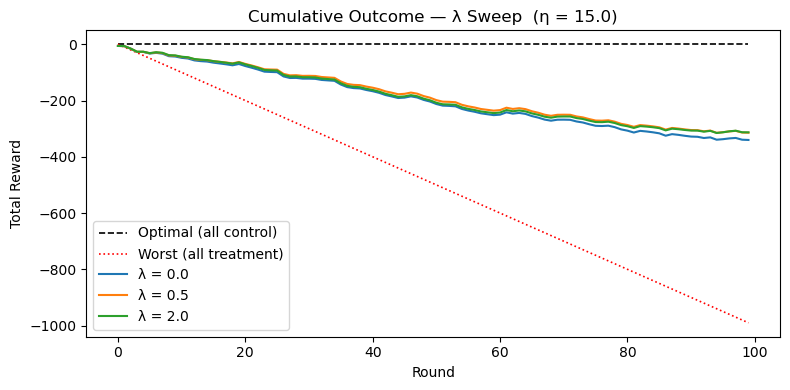

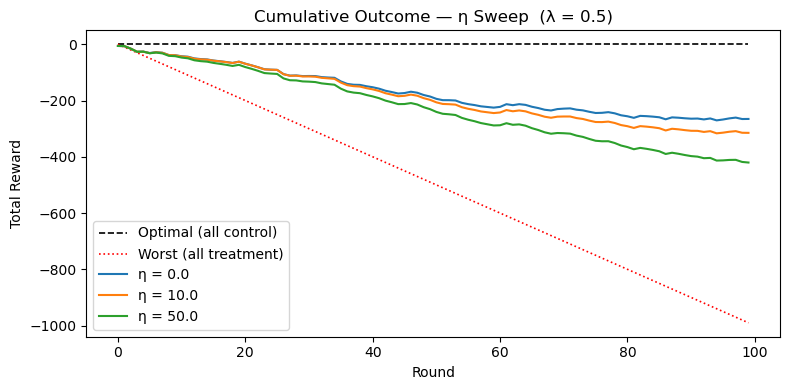

In [30]:

# Cumulative reward: lambda sweep only (shows cost of not experimenting)
fig, ax = plt.subplots(figsize=(8, 4))
optimal_cumrew = np.zeros(T)
worst_cumrew   = n_per_round * rounds * true_effect
ax.plot(optimal_cumrew, linestyle='--', color='black', linewidth=1.2, label='Optimal (all control)')
ax.plot(worst_cumrew,   linestyle=':',  color='red',   linewidth=1.2, label='Worst (all treatment)')
for lw in lambda_values:
    m = cumrew_lambda[lw].mean()
    s = cumrew_lambda[lw].std()
    ax.plot(rounds, m.values, label=f'λ = {lw}')
    # ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.set_title(f'Cumulative Outcome — λ Sweep  (η = {eta_fixed})')
ax.set_xlabel('Round')
ax.set_ylabel('Total Reward')
ax.legend()
plt.tight_layout()
plt.show()

# Cumulative reward: eta sweep only (shows cost of not experimenting)
fig, ax = plt.subplots(figsize=(8, 4))
optimal_cumrew = np.zeros(T)
worst_cumrew   = n_per_round * rounds * true_effect
ax.plot(optimal_cumrew, linestyle='--', color='black', linewidth=1.2, label='Optimal (all control)')
ax.plot(worst_cumrew,   linestyle=':',  color='red',   linewidth=1.2, label='Worst (all treatment)')
for ev in eta_values:
    m = cumrew_eta[ev].mean()
    s = cumrew_eta[ev].std()
    ax.plot(rounds, m.values, label=f'η = {ev}')
    # ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.set_title(f'Cumulative Outcome — η Sweep  (λ = {lambda_fixed})')
ax.set_xlabel('Round')
ax.set_ylabel('Total Reward')
ax.legend()
plt.tight_layout()
plt.show()





## Takeaway
We have shown that agents in this simulation that are not inclined for variance and not inclined for certainty in their outcomes will experiment less. This makes intuitive sense.

But agents in the simulation that continue to be okay with variance in their outcomes and wanting certainty in their decision will have lower total outcomes and be less profitable. This is because they continue to experiment even after they already have a good idea of what is the best action to take. 

The gap in these simulations is that we have not completely baked in the dynamics of information. Over time the organization figures out the best action to take and stops experimenting. That is not accurately reflected in here and would need to be done with a dynamic programming problem of learning.t
